# EDA - Encuesta de Ocupación Hotelera (EOH): perfil del viajero y demanda de pernoctaciones

**Equipo:** Equip_34
**Fecha:** 21/07/2026
**Datasets:** `EOH_2039_raw_20_07_2026.csv`, `EOH_2069_raw_20_07_2026.csv`, `EOH_2074_raw_20_07_2026.csv`, `EOH_2078_raw_20_07_2026.csv` (INE, Encuesta de Ocupación Hotelera)

Este notebook cubre el **EDA de la demanda turística oficial** (EOH). Se complementa con `EDA_21_07_2026.ipynb`, que analiza la **oferta de StaySpain**; el contraste explícito entre ambas fuentes se dejará para un notebook de análisis específico posterior.

**Periodo de análisis:** el foco del EDA es **2023-2025 (3 años completos)**. Las series de las 4 tablas arrancan en 1999 o 2005 y llegan hasta mayo de 2026, pero se descartan tanto los años anteriores a 2023 (menos representativos de la demanda actual) como 2026 (año en curso, incompleto), para trabajar con un periodo estable y comparable entre las 4 tablas.

## Índice

1. **Carga de datos e importación de librerías** — lectura de las 4 tablas EOH con el mismo criterio de localización de rutas que el resto de notebooks del proyecto.
2. **Preparación común (`Periodo` y `Total`)** — las 4 tablas comparten el mismo formato de periodo (`AAAAMmm`) y de cifra (formato español, con `.`/`..` como marca de dato no disponible o secreto estadístico del INE). Se parsean una sola vez con funciones reutilizables, sin sobrescribir los CSV originales.
3. **Ámbito geográfico** — correspondencia entre las 8 ciudades/mercados de StaySpain y las unidades geográficas disponibles en la EOH (punto turístico, zona turística, provincia, comunidad autónoma).
4. **Tabla 2074 — Viajeros y pernoctaciones por comunidad autónoma y procedencia**: visión general, estancia media (pernoctaciones / viajeros) por comunidad autónoma y origen, estacionalidad y peso nacional/extranjero.
5. **Tabla 2069 — Perfil de procedencia por provincia de destino**: visión general y perfil de las comunidades autónomas de origen de los viajeros que pernoctan en las provincias donde StaySpain está presente.
6. **Tabla 2039 — Zonas turísticas**: foco en Illes Balears (Mallorca y Menorca), únicos mercados de StaySpain sin punto turístico municipal propio.
7. **Tabla 2078 — Puntos turísticos**: foco en Barcelona, Madrid, Girona, València, Málaga y Sevilla — estacionalidad y procedencia al nivel más fino disponible.
8. **Síntesis conjunta (viajero extranjero)** — comparativa de los 8 mercados de StaySpain en un mismo cuadro (mes de mayor demanda, peso del turismo extranjero, estancia media).
9. **Síntesis conjunta (viajero nacional)** — mismo cuadro que el punto 8, para el viajero residente en España, para poder comparar ambos perfiles.
10. **Conclusiones y próximos pasos.**
11. **Notas para Data Cleaning, Data Transformation y tareas de los analistas** — aspectos a tener en cuenta en las siguientes fases del proyecto y reparto del trabajo de análisis por bloques de la pregunta de negocio.

> **Nota:** Este notebook explora datos oficiales agregados del INE (no microdatos de reservas). El parseo de `Periodo` y `Total` se realiza únicamente para el EDA y no se guarda como CSV; no sustituye una fase formal de Data Cleaning.

## 1. Carga de datos e importación de librerías

In [1]:
# Librerías básicas para EDA
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Estilo simple para los gráficos
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
# Parámetros de ejecución: actualizar solo esta sección cuando cambien los datasets
DATASET_FILES = {
    "2039": "EOH_2039_raw_20_07_2026.csv",   # Zonas turísticas
    "2069": "EOH_2069_raw_20_07_2026.csv",   # % procedencia por provincia de destino
    "2074": "EOH_2074_raw_20_07_2026.csv",   # CCAA / provincia x procedencia (valores absolutos)
    "2078": "EOH_2078_raw_20_07_2026.csv",   # Puntos turísticos
}
FECHA_EDA = pd.Timestamp.today().strftime("%d/%m/%Y")

# Periodo de análisis: el EDA se centra en 2023-2025 (3 años completos), dejando
# fuera 2026 (año en curso, incompleto) y los años previos a 2023.
PERIODO_INICIO = pd.Timestamp("2023-01-01")
PERIODO_FIN = pd.Timestamp("2025-12-01")


def encontrar_raiz_proyecto(nombre_carpeta="Equip_34"):
    """Busca la carpeta raíz del proyecto desde el directorio actual."""
    actual = Path.cwd()

    for carpeta in [actual] + list(actual.parents):
        if carpeta.name == nombre_carpeta:
            return carpeta

    raise FileNotFoundError(
        f"No se encontró la carpeta '{nombre_carpeta}' "
        f"subiendo desde {actual}"
    )


raiz_proyecto = encontrar_raiz_proyecto("Equip_34")

# Las tablas de la EOH (INE) se exportan con ';' como separador y BOM utf-8,
# a diferencia del dataset de StaySpain (separado por comas). Se mantiene el
# mismo criterio de localización de rutas que en el resto de notebooks.
dfs_raw = {}
for clave, nombre_archivo in DATASET_FILES.items():
    ruta_csv = raiz_proyecto / "Data" / nombre_archivo
    if not ruta_csv.exists():
        raise FileNotFoundError(f"No se encontró el dataset: {nombre_archivo}")
    dfs_raw[clave] = pd.read_csv(ruta_csv, sep=";", encoding="utf-8-sig")

print(f"Fecha de ejecución: {FECHA_EDA}")
for clave, df in dfs_raw.items():
    print(f"Tabla {clave}: {df.shape[0]:>7,d} filas x {df.shape[1]} columnas -> {list(df.columns)}")

Fecha de ejecución: 21/07/2026
Tabla 2039:  63,168 filas x 5 columnas -> ['Zonas Turísticas', 'Viajeros y pernoctaciones', 'Residencia', 'Periodo', 'Total']
Tabla 2069: 697,480 filas x 7 columnas -> ['Totales Territoriales', 'Provincias', 'Viajeros y pernoctaciones', 'Totales Territoriales.1', 'Comunidades y Ciudades Autónomas', 'Periodo', 'Total']
Tabla 2074: 138,180 filas x 8 columnas -> ['Totales Territoriales', 'Comunidades y Ciudades Autónomas', 'Provincias', 'Viajeros y pernoctaciones', 'Residencia: Nivel 1', 'Residencia: Nivel 2', 'Periodo', 'Total']
Tabla 2078: 141,864 filas x 5 columnas -> ['Puntos turísticos', 'Viajeros y pernoctaciones', 'Residencia', 'Periodo', 'Total']


## 2. Preparación común: parseo de `Periodo` y `Total`

Las 4 tablas comparten dos convenciones del INE:

- `Periodo` con formato `AAAAMmm` (p. ej. `2026M05`).
- `Total` en formato numérico español (`.` de miles, `,` decimal), donde `.` o `..` indican dato no disponible o secreto estadístico (célula con muestra insuficiente).

Se definen dos funciones reutilizables y se aplican una sola vez sobre una copia de cada tabla, conservando `dfs_raw` intacto para las comprobaciones de la sección de visión general de cada tabla.

In [3]:
def parsear_total(serie):
    """Convierte 'Total' (formato INE) a float; '.'/'..' se interpretan como NaN."""
    texto = serie.astype("string").str.strip()
    texto = texto.replace({".": pd.NA, "..": pd.NA})
    texto = texto.str.replace(".", "", regex=False).str.replace(",", ".", regex=False)
    return pd.to_numeric(texto, errors="coerce").astype("float64")


def parsear_periodo(serie):
    """Convierte 'AAAAMmm' en Timestamp del primer día del mes correspondiente."""
    return pd.to_datetime(serie.str.replace("M", "-", regex=False) + "-01", format="%Y-%m-%d")


dfs = {}
for clave, df in dfs_raw.items():
    df_prep = df.copy()
    df_prep["Total_num"] = parsear_total(df_prep["Total"])
    df_prep["Fecha"] = parsear_periodo(df_prep["Periodo"])
    dfs[clave] = df_prep

df_2039, df_2069, df_2074, df_2078 = dfs["2039"], dfs["2069"], dfs["2074"], dfs["2078"]

In [4]:
# Validación: los nulos "reales" de Total deben coincidir con los introducidos por el parseo
for clave, df in dfs.items():
    nulos_originales = df["Total"].isna().sum() + df["Total"].isin([".", ".."]).sum()
    nulos_tras_parseo = df["Total_num"].isna().sum()
    rango_fechas = f'{df["Fecha"].min().strftime("%Y-%m")} a {df["Fecha"].max().strftime("%Y-%m")}'
    print(f"Tabla {clave}: nulos antes={nulos_originales:>6,d}  tras parseo={nulos_tras_parseo:>6,d}  "
          f"rango temporal={rango_fechas}")

Tabla 2039: nulos antes=13,876  tras parseo=13,876  rango temporal=1999-01 a 2026-05
Tabla 2069: nulos antes=40,631  tras parseo=40,631  rango temporal=1999-01 a 2026-05
Tabla 2074: nulos antes=    85  tras parseo=    85  rango temporal=1999-01 a 2026-05
Tabla 2078: nulos antes=44,996  tras parseo=44,996  rango temporal=2005-01 a 2026-05


El parseo no introduce nulos adicionales: coinciden exactamente con las celdas marcadas por el INE como no disponibles o sujetas a secreto estadístico (municipios/orígenes con muestra insuficiente). Estas celdas se excluyen de los cálculos agregados, no se imputan. Las 4 series cubren un rango temporal amplio (desde 1999 o 2005 hasta mayo de 2026); a partir de aquí, todo el análisis se filtra al periodo **2023-2025** (`PERIODO_INICIO`/`PERIODO_FIN`), 3 años completos y recientes, comparables entre sí y no distorsionados por el año en curso.

## 3. Ámbito geográfico: de las ciudades StaySpain a las tablas EOH

StaySpain está presente en 8 ciudades/mercados: Barcelona, Madrid, Girona, València, Málaga, Sevilla, Mallorca y Menorca. Las tablas de la EOH ofrecen distintos niveles de granularidad geográfica, y no todas cubren estos mercados de la misma forma:

- **Puntos turísticos (2078):** nivel municipal. Cubre directamente Barcelona, Madrid, Girona, València, Málaga y Sevilla, pero **no existe un punto turístico para "Mallorca" ni "Menorca"**, ya que son ámbitos insulares y no municipios.
- **Zonas turísticas (2039):** nivel intermedio, con zonas específicas `Isla De Mallorca` e `Isla De Menorca`, que sí permiten distinguir estos dos mercados.
- **Provincia (2069) y comunidad autónoma (2074):** a nivel de comunidad autónoma, tres pares de mercados quedan agrupados bajo la misma CCAA — Barcelona y Girona (Cataluña), Málaga y Sevilla (Andalucía), y Mallorca y Menorca (Illes Balears) — y dejan de ser distinguibles entre sí. A nivel de provincia solo Mallorca y Menorca siguen sin distinguirse, porque comparten la misma fila ("07 Balears, Illes"); Barcelona/Girona y Málaga/Sevilla sí son provincias distintas y pueden analizarse por separado en la tabla 2069.

Se define a continuación la correspondencia que se usará en el resto del notebook.

In [5]:
CIUDADES_STAYSPAIN = ["Barcelona", "Madrid", "Girona", "Valencia", "Málaga", "Sevilla", "Mallorca", "Menorca"]

# Punto turístico EOH (tabla 2078) - no existe para Mallorca/Menorca
MAPEO_PUNTO_TURISTICO = {
    "Barcelona": "08019 Barcelona",
    "Madrid": "28079 Madrid",
    "Girona": "17079 Girona",
    "Valencia": "46250 València",
    "Málaga": "29067 Málaga",
    "Sevilla": "41091 Sevilla",
}

# Zona turística EOH (tabla 2039) - cubre específicamente Mallorca y Menorca
MAPEO_ZONA_TURISTICA = {
    "Mallorca": "Baleares (Illes): Isla De Mallorca",
    "Menorca": "Baleares (Illes): Isla De Menorca",
}

# Provincia EOH (tablas 2069/2074)
MAPEO_PROVINCIA = {
    "Barcelona": "08 Barcelona",
    "Madrid": "28 Madrid",
    "Girona": "17 Girona",
    "Valencia": "46 Valencia/València",
    "Málaga": "29 Málaga",
    "Sevilla": "41 Sevilla",
    "Mallorca": "07 Balears, Illes",
    "Menorca": "07 Balears, Illes",
}

# Comunidad autónoma EOH (tabla 2074)
MAPEO_CCAA = {
    "Barcelona": "09 Cataluña",
    "Girona": "09 Cataluña",
    "Madrid": "13 Madrid, Comunidad de",
    "Valencia": "10 Comunitat Valenciana",
    "Málaga": "01 Andalucía",
    "Sevilla": "01 Andalucía",
    "Mallorca": "04 Balears, Illes",
    "Menorca": "04 Balears, Illes",
}

tabla_correspondencia = pd.DataFrame({
    "punto_turistico_2078": pd.Series(MAPEO_PUNTO_TURISTICO),
    "zona_turistica_2039": pd.Series(MAPEO_ZONA_TURISTICA),
    "provincia_2069_2074": pd.Series(MAPEO_PROVINCIA),
    "ccaa_2074": pd.Series(MAPEO_CCAA),
}).reindex(CIUDADES_STAYSPAIN)
tabla_correspondencia

,punto_turistico_2078,zona_turistica_2039,provincia_2069_2074,ccaa_2074
Barcelona,08019 Barcelona,NaN,08 Barcelona,09 Cataluña
Madrid,28079 Madrid,NaN,28 Madrid,"13 Madrid, Comunidad de"
Girona,17079 Girona,NaN,17 Girona,09 Cataluña
Valencia,46250 València,NaN,46 Valencia/València,10 Comunitat Valenciana
Málaga,29067 Málaga,NaN,29 Málaga,01 Andalucía
Sevilla,41091 Sevilla,NaN,41 Sevilla,01 Andalucía
Mallorca,NaN,Baleares (Illes): Isla De Mallorca,"07 Balears, Illes","04 Balears, Illes"
Menorca,NaN,Baleares (Illes): Isla De Menorca,"07 Balears, Illes","04 Balears, Illes"


La tabla anterior confirma visualmente lo comentado al inicio de esta sección: Mallorca y Menorca son las únicas dos filas con el mismo valor de provincia y de CCAA, de ahí que en el resto del notebook se usen sus respectivas zonas turísticas (2039, sección 6) en vez de la provincia o la CCAA.

## 4. Tabla 2074 — Viajeros y pernoctaciones por comunidad autónoma y procedencia

Esta tabla aporta **valores absolutos** de viajeros y pernoctaciones por comunidad autónoma/provincia, desglosados por procedencia (residentes en España / residentes en el extranjero). Es la única de las 4 tablas que permite calcular directamente la **estancia media** (pernoctaciones ÷ viajeros) por comunidad autónoma y origen.

### 4.1. Visión general

In [6]:
print("Filas:", df_2074.shape[0], " Columnas:", df_2074.shape[1])
print("Filas duplicadas:", df_2074.duplicated().sum())
df_2074.dtypes

Filas: 138180  Columnas: 10
Filas duplicadas: 0


Totales Territoriales                       object
Comunidades y Ciudades Autónomas            object
Provincias                                  object
Viajeros y pernoctaciones                   object
Residencia: Nivel 1                         object
Residencia: Nivel 2                         object
Periodo                                     object
Total                                       object
Total_num                                  float64
Fecha                               datetime64[ns]
dtype: object

In [7]:
# Nulos por columna (sobre el dataframe preparado)
df_2074.isna().sum()

Totales Territoriales                   0
Comunidades y Ciudades Autónomas     1974
Provincias                          39480
Viajeros y pernoctaciones               0
Residencia: Nivel 1                     0
Residencia: Nivel 2                 46060
Periodo                                 0
Total                                  10
Total_num                              85
Fecha                                   0
dtype: int64

In [8]:
print(df_2074["Viajeros y pernoctaciones"].value_counts())
print()
print(df_2074["Residencia: Nivel 1"].value_counts(dropna=False))
print()
print(df_2074["Residencia: Nivel 2"].value_counts(dropna=False))

Viajeros y pernoctaciones
Viajero           69090
Pernoctaciones    69090
Name: count, dtype: int64

Residencia: Nivel 1
Total    138180
Name: count, dtype: int64

Residencia: Nivel 2
NaN                            46060
Residentes en España           46060
Residentes en el Extranjero    46060
Name: count, dtype: int64


`Residencia: Nivel 1` toma siempre el valor `Total` y no aporta información (es un nivel jerárquico vacío en esta consulta del INE); la procedencia efectiva está en `Residencia: Nivel 2` (España / Extranjero), presente solo en las filas desglosadas por origen. Las filas con `Residencia: Nivel 2` nulo son el total agregado (todas las procedencias) y se excluyen de los cálculos de estancia media por origen para no duplicar el conteo.

También hay dos niveles geográficos en la misma tabla: filas de comunidad autónoma (`Provincias` nulo) y filas de provincia. Para la estancia media por comunidad autónoma se usa el nivel de comunidad autónoma.

### 4.2. Estancia media por comunidad autónoma y procedencia (2023-2025)

In [9]:
ccaa_interes = sorted(set(MAPEO_CCAA.values()))

nivel_ccaa = df_2074[
    df_2074["Provincias"].isna()
    & df_2074["Comunidades y Ciudades Autónomas"].isin(ccaa_interes)
    & df_2074["Residencia: Nivel 2"].notna()
    & df_2074["Fecha"].between(PERIODO_INICIO, PERIODO_FIN)
]

# Se suman viajeros y pernoctaciones de los 3 años del periodo antes de dividir,
# en vez de promediar cocientes mensuales, para no dar más peso a meses de bajo volumen.
estancia_ccaa = nivel_ccaa.pivot_table(
    index=["Comunidades y Ciudades Autónomas", "Residencia: Nivel 2"],
    columns="Viajeros y pernoctaciones",
    values="Total_num",
    aggfunc="sum",
)
estancia_ccaa["estancia_media"] = estancia_ccaa["Pernoctaciones"] / estancia_ccaa["Viajero"]
estancia_ccaa = estancia_ccaa.round(2)
estancia_ccaa

Viajeros y pernoctaciones                                     Pernoctaciones  \
Comunidades y Ciudades Autónomas Residencia: Nivel 2                           
01 Andalucía                     Residentes en España             76247309.0   
                                 Residentes en el Extranjero      91782385.0   
04 Balears, Illes                Residentes en España             16078648.0   
                                 Residentes en el Extranjero     169393339.0   
09 Cataluña                      Residentes en España             50535640.0   
                                 Residentes en el Extranjero     129161035.0   
10 Comunitat Valenciana          Residentes en España             45066826.0   
                                 Residentes en el Extranjero      46618944.0   
13 Madrid, Comunidad de          Residentes en España             34888843.0   
                                 Residentes en el Extranjero      44720615.0   

Viajeros y pernoctaciones                                        Viajero  \
Comunidades y Ciudades Autónomas Residencia: Nivel 2                       
01 Andalucía                     Residentes en España         32278982.0   
                                 Residentes en el Extranjero  28296952.0   
04 Balears, Illes                Residentes en España          4659544.0   
                                 Residentes en el Extranjero  31700229.0   
09 Cataluña                      Residentes en España         23633725.0   
                                 Residentes en el Extranjero  41757893.0   
10 Comunitat Valenciana          Residentes en España         16305206.0   
                                 Residentes en el Extranjero  12897358.0   
13 Madrid, Comunidad de          Residentes en España         19742905.0   
                                 Residentes en el Extranjero  19601579.0   

Viajeros y pernoctaciones                                     estancia_media  
Comunidades y Ciudades Autónomas Residencia: Nivel 2                          
01 Andalucía                     Residentes en España                   2.36  
                                 Residentes en el Extranjero            3.24  
04 Balears, Illes                Residentes en España                   3.45  
                                 Residentes en el Extranjero            5.34  
09 Cataluña                      Residentes en España                   2.14  
                                 Residentes en el Extranjero            3.09  
10 Comunitat Valenciana          Residentes en España                   2.76  
                                 Residentes en el Extranjero            3.61  
13 Madrid, Comunidad de          Residentes en España                   1.77  
                                 Residentes en el Extranjero            2.28

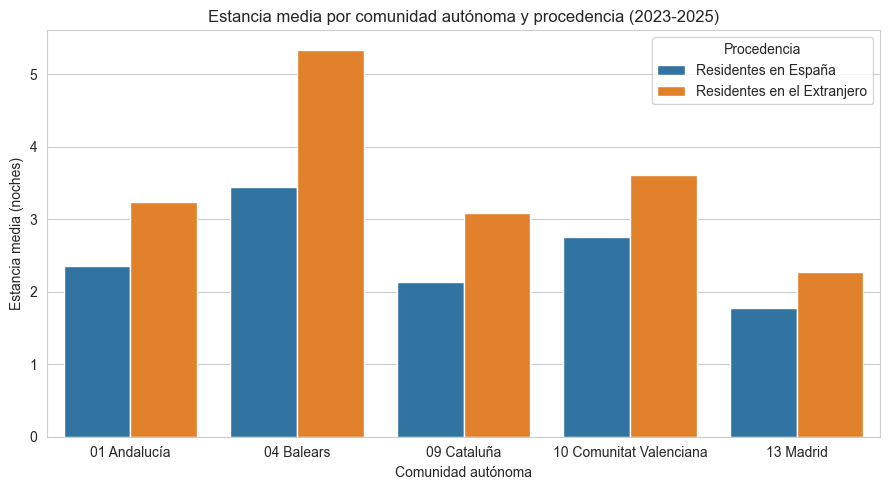

In [10]:
plot_data = estancia_ccaa.reset_index()
plot_data["ccaa_corta"] = plot_data["Comunidades y Ciudades Autónomas"].str.split(",").str[0].str.split(":").str[0]

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=plot_data,
    x="ccaa_corta",
    y="estancia_media",
    hue="Residencia: Nivel 2",
    ax=ax,
)
ax.set_title("Estancia media por comunidad autónoma y procedencia (2023-2025)")
ax.set_xlabel("Comunidad autónoma")
ax.set_ylabel("Estancia media (noches)")
ax.legend(title="Procedencia")
plt.tight_layout()
plt.show()

En las 5 comunidades autónomas de interés, los viajeros extranjeros pernoctan más noches de media que los residentes en España, con la brecha más amplia en Illes Balears. Esto es un indicador directo de perfil de viajero por comunidad autónoma: las estrategias de estancia mínima/precio por noche podrían diferenciarse por procedencia, especialmente en Illes Balears.

### 4.3. Estacionalidad: pernoctaciones mensuales por comunidad autónoma

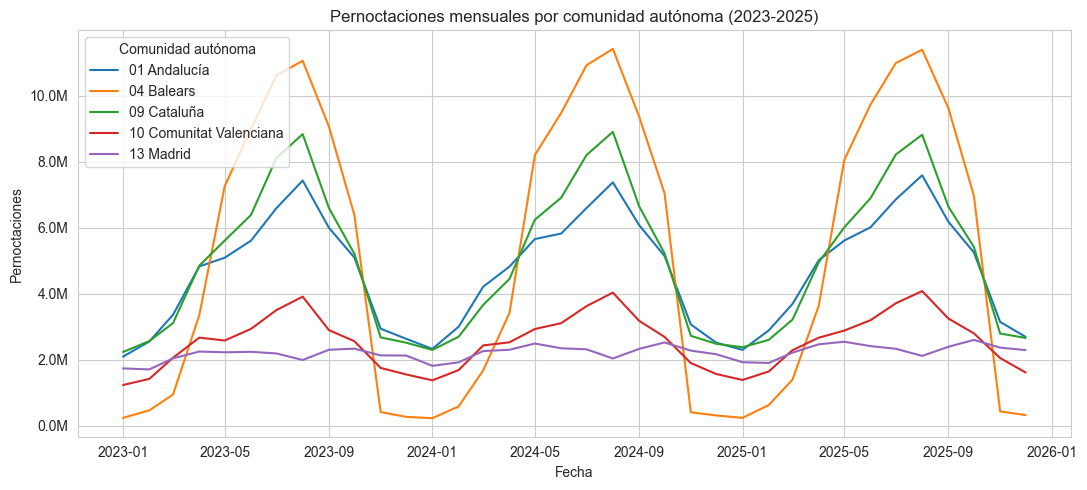

In [11]:
serie_ccaa = df_2074[
    df_2074["Provincias"].isna()
    & df_2074["Comunidades y Ciudades Autónomas"].isin(ccaa_interes)
    & df_2074["Residencia: Nivel 2"].isna()
    & (df_2074["Viajeros y pernoctaciones"] == "Pernoctaciones")
    & df_2074["Fecha"].between(PERIODO_INICIO, PERIODO_FIN)
].copy()
serie_ccaa["ccaa_corta"] = serie_ccaa["Comunidades y Ciudades Autónomas"].str.split(",").str[0].str.split(":").str[0]

fig, ax = plt.subplots(figsize=(11, 5))
for ccaa, grupo in serie_ccaa.groupby("ccaa_corta"):
    grupo_ordenado = grupo.sort_values("Fecha")
    ax.plot(grupo_ordenado["Fecha"], grupo_ordenado["Total_num"], label=ccaa)
ax.set_title("Pernoctaciones mensuales por comunidad autónoma (2023-2025)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Pernoctaciones")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.legend(title="Comunidad autónoma")
plt.tight_layout()
plt.show()

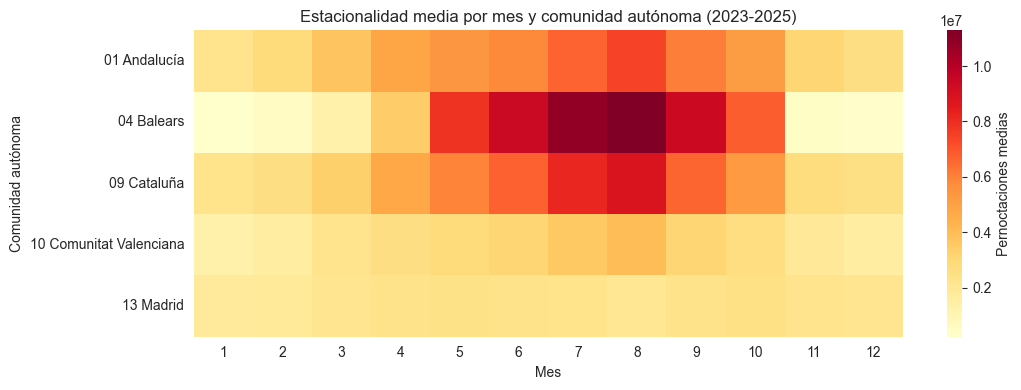

In [12]:
serie_ccaa["mes"] = serie_ccaa["Fecha"].dt.month
estacionalidad_ccaa = serie_ccaa.groupby(["ccaa_corta", "mes"])["Total_num"].mean().unstack("mes")

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(estacionalidad_ccaa, cmap="YlOrRd", annot=False, cbar_kws={"label": "Pernoctaciones medias"}, ax=ax)
ax.set_title("Estacionalidad media por mes y comunidad autónoma (2023-2025)")
ax.set_xlabel("Mes")
ax.set_ylabel("Comunidad autónoma")
plt.tight_layout()
plt.show()

Andalucía, Cataluña, Illes Balears y Comunitat Valenciana muestran un patrón estacional con pico en agosto, aunque de intensidad muy distinta: Illes Balears concentra su demanda de forma mucho más marcada en esos meses. **Madrid es la excepción**: no solo tiene la curva más plana de las 5, sino que su pico de demanda está en octubre, no en verano. Esto sugiere que la política de precios/disponibilidad estacional debería ser más agresiva en Illes Balears que en el resto, y que Madrid necesita un calendario de temporada alta distinto al del resto de comunidades.

### 4.4. Peso del turismo extranjero por comunidad autónoma (evolución)

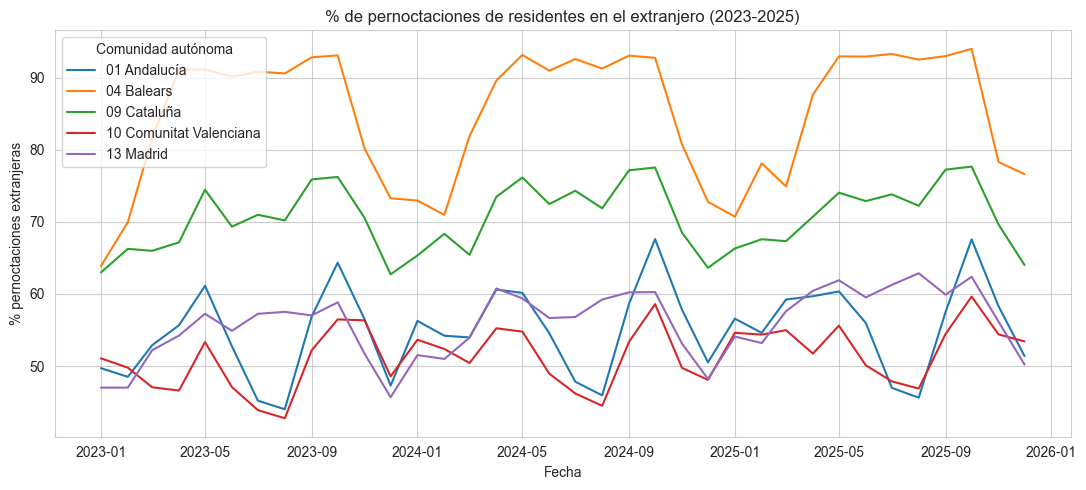

In [13]:
serie_origen = df_2074[
    df_2074["Provincias"].isna()
    & df_2074["Comunidades y Ciudades Autónomas"].isin(ccaa_interes)
    & df_2074["Residencia: Nivel 2"].notna()
    & (df_2074["Viajeros y pernoctaciones"] == "Pernoctaciones")
    & df_2074["Fecha"].between(PERIODO_INICIO, PERIODO_FIN)
].copy()
serie_origen["ccaa_corta"] = serie_origen["Comunidades y Ciudades Autónomas"].str.split(",").str[0].str.split(":").str[0]

peso_extranjero = (
    serie_origen
    .pivot_table(index=["ccaa_corta", "Fecha"], columns="Residencia: Nivel 2", values="Total_num")
    .assign(pct_extranjero=lambda d: d["Residentes en el Extranjero"] / (d["Residentes en España"] + d["Residentes en el Extranjero"]) * 100)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
for ccaa, grupo in peso_extranjero.groupby("ccaa_corta"):
    ax.plot(grupo["Fecha"], grupo["pct_extranjero"], label=ccaa)
ax.set_title("% de pernoctaciones de residentes en el extranjero (2023-2025)")
ax.set_xlabel("Fecha")
ax.set_ylabel("% pernoctaciones extranjeras")
ax.legend(title="Comunidad autónoma")
plt.tight_layout()
plt.show()

Illes Balears (85% de media 2023-2025) y Cataluña (71%) dependen de forma estructural del turismo extranjero, muy por encima del resto; Madrid (56%), Andalucía (55%) y Comunitat Valenciana (51%) tienen un peso del turismo nacional bastante mayor y más parecido entre sí. El perfil de procedencia condiciona qué canales de venta y qué idiomas priorizar en cada mercado.

## 5. Tabla 2069 — Perfil de procedencia por provincia de destino

Esta tabla ofrece la **distribución porcentual** de viajeros/pernoctaciones de cada provincia de destino según la comunidad autónoma de residencia del viajero. Es la tabla más pesada (~700.000 filas), por lo que el EDA general se limita a su estructura y se filtra pronto a las provincias de interés antes de cualquier análisis.

### 5.1. Visión general

In [14]:
print("Filas:", df_2069.shape[0], " Columnas:", df_2069.shape[1])
print("Filas duplicadas:", df_2069.duplicated().sum())
print()
print("Nº de provincias de destino:", df_2069["Provincias"].nunique())
print("Nº de comunidades autónomas de origen:", df_2069["Comunidades y Ciudades Autónomas"].nunique())
print()
print(df_2069["Viajeros y pernoctaciones"].value_counts())

Filas: 697480  Columnas: 9


Filas duplicadas: 0

Nº de provincias de destino: 52
Nº de comunidades autónomas de origen: 19

Viajeros y pernoctaciones
Viajero           348740
Pernoctaciones    348740
Name: count, dtype: int64


Cada provincia de destino aparece tanto en la columna `Provincias` (fila = total de esa provincia, `Comunidades y Ciudades Autónomas` nulo) como cruzada con cada una de las 19 comunidades autónomas de origen (fila = % de esa comunidad sobre el total de la provincia). Se filtra a las filas cruzadas para obtener el perfil de procedencia.

### 5.2. Perfil de procedencia (comunidades autónomas de origen) por provincia de interés

In [15]:
provincias_interes = sorted(set(MAPEO_PROVINCIA.values()))

sub_2069 = df_2069[
    df_2069["Provincias"].isin(provincias_interes)
    & df_2069["Comunidades y Ciudades Autónomas"].notna()
    & (df_2069["Viajeros y pernoctaciones"] == "Pernoctaciones")
]

periodo_2069 = sub_2069[sub_2069["Fecha"].between(PERIODO_INICIO, PERIODO_FIN)]

perfil_procedencia = (
    periodo_2069
    .groupby(["Provincias", "Comunidades y Ciudades Autónomas"])["Total_num"]
    .mean()
    .reset_index()
)
top3_por_provincia = (
    perfil_procedencia
    .sort_values(["Provincias", "Total_num"], ascending=[True, False])
    .groupby("Provincias")
    .head(3)
)
top3_por_provincia

,Provincias,Comunidades y Ciudades Autónomas,Total_num
3,"07 Balears, Illes","04 Balears, Illes",33.842222
12,"07 Balears, Illes","13 Madrid, Comunidad de",16.829167
8,"07 Balears, Illes",09 Cataluña,14.795278
27,08 Barcelona,09 Cataluña,43.166667
31,08 Barcelona,"13 Madrid, Comunidad de",20.250833
19,08 Barcelona,01 Andalucía,6.949722
46,17 Girona,09 Cataluña,72.507778
50,17 Girona,"13 Madrid, Comunidad de",7.070278
47,17 Girona,10 Comunitat Valenciana,4.296667
69,28 Madrid,"13 Madrid, Comunidad de",24.501667


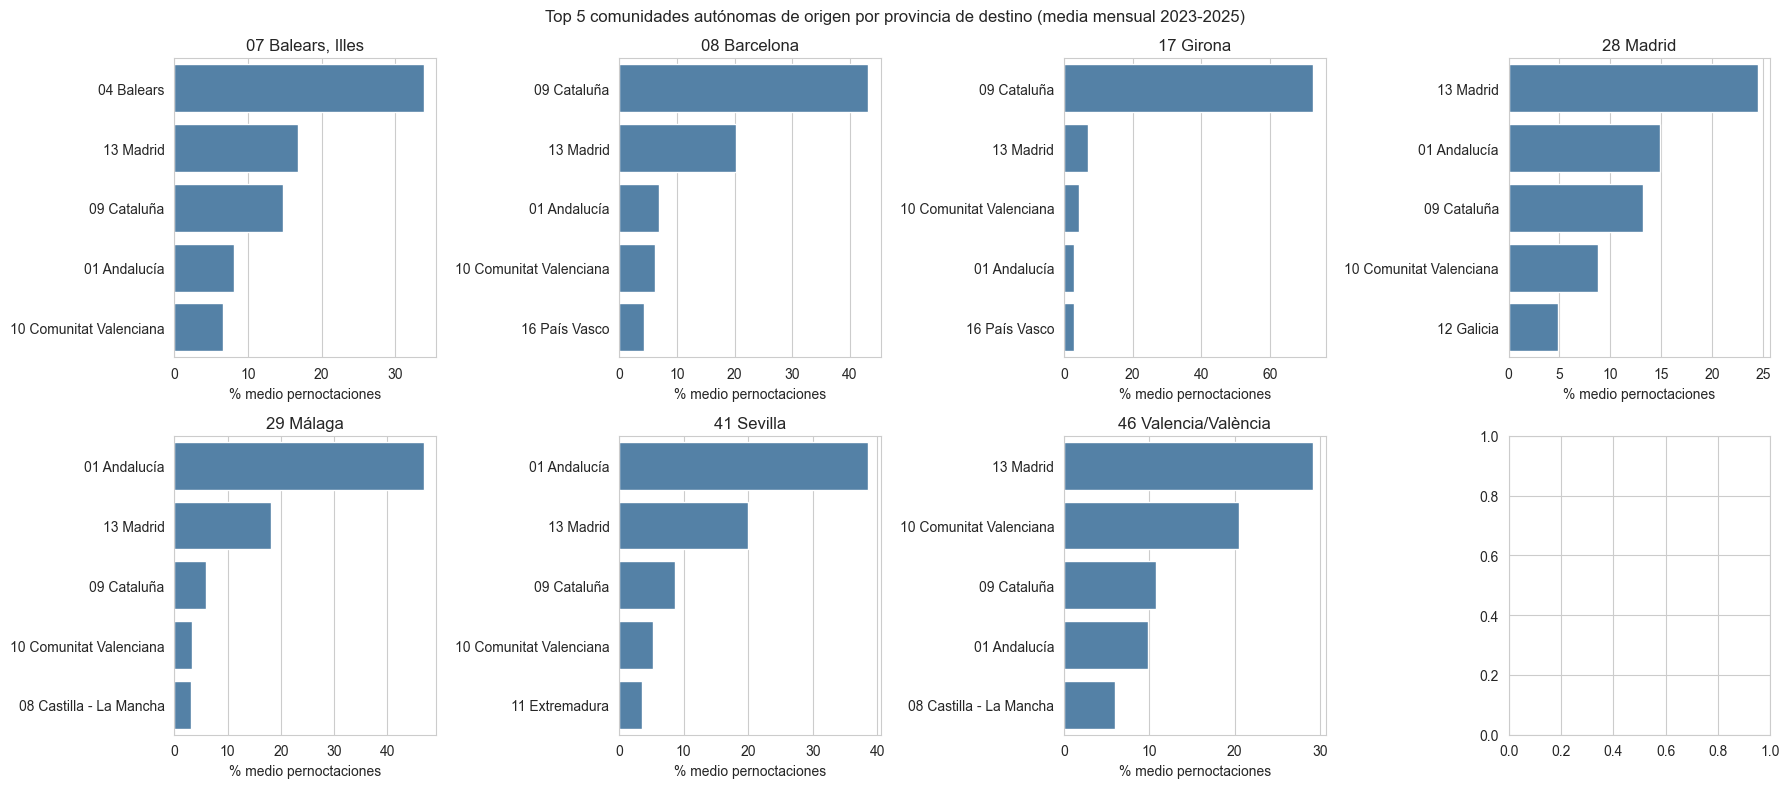

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=False)
for ax, provincia in zip(axes.flat, provincias_interes):
    datos = (
        perfil_procedencia[perfil_procedencia["Provincias"] == provincia]
        .sort_values("Total_num", ascending=False)
        .head(5)
    )
    datos["ccaa_corta"] = datos["Comunidades y Ciudades Autónomas"].str.split(",").str[0].str.split(":").str[0]
    sns.barplot(data=datos, y="ccaa_corta", x="Total_num", ax=ax, color="steelblue")
    ax.set_title(provincia)
    ax.set_xlabel("% medio pernoctaciones")
    ax.set_ylabel("")
fig.suptitle("Top 5 comunidades autónomas de origen por provincia de destino (media mensual 2023-2025)")
plt.tight_layout()
plt.show()

En 6 de las 7 provincias de interés, el origen individual más importante es la propia comunidad autónoma de la provincia (efecto proximidad): Cataluña para Barcelona (43%) y, de forma mucho más extrema, para Girona (73%); Andalucía para Málaga (47%) y Sevilla (39%); Madrid para Madrid (25%); Illes Balears para Illes Balears (34%). La intensidad de este efecto varía mucho: es moderado en Madrid o Illes Balears y extremo en Girona, probablemente por su cercanía a otras ciudades catalanas para escapadas cortas.

**València es la única excepción:** su origen doméstico más importante no es la propia Comunitat Valenciana (21%, en segundo lugar), sino Madrid (29%). Esta información es la base para segmentar campañas de marketing nacional por origen geográfico: en la mayoría de ciudades el público objetivo doméstico más natural es el de la propia región, pero en València conviene priorizar Madrid como origen principal.

Nota: Barcelona/Girona (dentro de Cataluña) y Málaga/Sevilla (dentro de Andalucía) son provincias distintas, por lo que esta tabla sí distingue el perfil de procedencia entre ambos pares de ciudades (a diferencia de Mallorca/Menorca, ver sección 3).

## 6. Tabla 2039 — Zonas turísticas: foco Illes Balears (Mallorca y Menorca)

Esta tabla es la única que distingue explícitamente entre `Isla De Mallorca` e `Isla De Menorca`, y aporta valores absolutos de viajeros/pernoctaciones desglosados por procedencia (España/Extranjero), igual que la tabla 2078 de puntos turísticos.

### 6.1. Visión general

In [17]:
print("Filas:", df_2039.shape[0], " Columnas:", df_2039.shape[1])
print("Filas duplicadas:", df_2039.duplicated().sum())
print("Nº de zonas turísticas:", df_2039["Zonas Turísticas"].nunique())
df_2039.isna().sum()

Filas: 63168  Columnas: 7
Filas duplicadas: 0
Nº de zonas turísticas: 48


Zonas Turísticas                 0
Viajeros y pernoctaciones        0
Residencia                       0
Periodo                          0
Total                        12648
Total_num                    13876
Fecha                            0
dtype: int64

### 6.2. Estacionalidad: Mallorca vs. Menorca

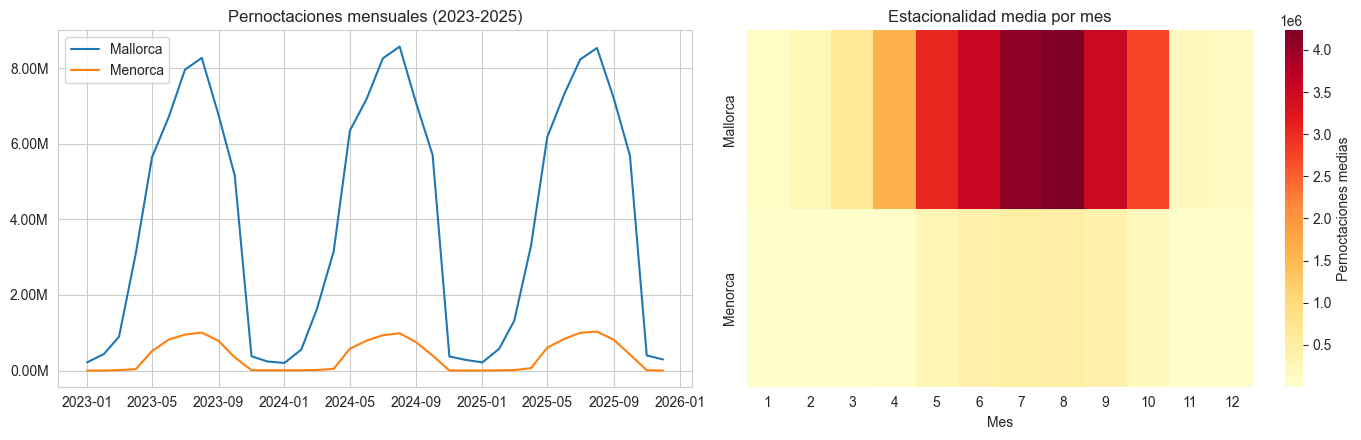

In [18]:
zonas_baleares = list(MAPEO_ZONA_TURISTICA.values())

sub_2039 = df_2039[
    df_2039["Zonas Turísticas"].isin(zonas_baleares)
    & (df_2039["Viajeros y pernoctaciones"] == "Pernoctaciones")
    & df_2039["Fecha"].between(PERIODO_INICIO, PERIODO_FIN)
].copy()
sub_2039["isla"] = sub_2039["Zonas Turísticas"].str.extract(r"Isla De (\w+)")
sub_2039["mes"] = sub_2039["Fecha"].dt.month

serie_islas = sub_2039.groupby(["isla", "Fecha"])["Total_num"].sum().reset_index()
estacionalidad_islas = sub_2039.groupby(["isla", "mes"])["Total_num"].mean().unstack("mes")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for isla, grupo in serie_islas.groupby("isla"):
    axes[0].plot(grupo["Fecha"], grupo["Total_num"], label=isla)
axes[0].set_title("Pernoctaciones mensuales (2023-2025)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.2f}M"))
axes[0].legend()

sns.heatmap(estacionalidad_islas, cmap="YlOrRd", ax=axes[1], cbar_kws={"label": "Pernoctaciones medias"})
axes[1].set_title("Estacionalidad media por mes")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

Mallorca concentra un volumen de pernoctaciones muy superior al de Menorca, y ambas comparten un patrón estacional muy marcado en julio-agosto. Como Mallorca representa la mayor parte del volumen de Illes Balears, su estacionalidad es prácticamente la misma que la del conjunto de la comunidad autónoma (sección 4.3); Menorca, con mucho menos volumen, tiene una estacionalidad todavía más marcada que la de Mallorca y que la del conjunto.

### 6.3. Procedencia nacional/extranjera: Mallorca vs. Menorca

In [19]:
sub_origen_2039 = df_2039[
    df_2039["Zonas Turísticas"].isin(zonas_baleares)
    & (df_2039["Viajeros y pernoctaciones"] == "Pernoctaciones")
    & df_2039["Fecha"].between(PERIODO_INICIO, PERIODO_FIN)
].copy()
sub_origen_2039["isla"] = sub_origen_2039["Zonas Turísticas"].str.extract(r"Isla De (\w+)")

peso_origen_islas = sub_origen_2039.pivot_table(index="isla", columns="Residencia", values="Total_num", aggfunc="sum")
peso_origen_islas["pct_extranjero"] = (
    peso_origen_islas["Residentes en el Extranjero"]
    / (peso_origen_islas["Residentes en España"] + peso_origen_islas["Residentes en el Extranjero"])
    * 100
).round(1)
peso_origen_islas

Residencia,Residentes en España,Residentes en el Extranjero,pct_extranjero
isla,,,
Mallorca,9893536.0,134525812.0,93.1
Menorca,2672762.0,11115678.0,80.6


Ambas islas dependen de forma muy mayoritaria del turismo extranjero, en línea con el peso ya observado para el conjunto de Illes Balears (sección 4.4).

## 7. Tabla 2078 — Puntos turísticos: foco Barcelona, Madrid, Girona, València, Málaga y Sevilla

Esta tabla ofrece la granularidad geográfica más fina disponible en la EOH (municipio), con el mismo desglose de procedencia que la tabla 2039.

### 7.1. Visión general

In [20]:
print("Filas:", df_2078.shape[0], " Columnas:", df_2078.shape[1])
print("Filas duplicadas:", df_2078.duplicated().sum())
print("Nº de puntos turísticos:", df_2078["Puntos turísticos"].nunique())
df_2078.isna().sum()

Filas: 141864  Columnas: 7
Filas duplicadas: 0
Nº de puntos turísticos: 138


Puntos turísticos                0
Viajeros y pernoctaciones        0
Residencia                       0
Periodo                          0
Total                        34582
Total_num                    44996
Fecha                            0
dtype: int64

### 7.2. Estacionalidad comparada entre ciudades

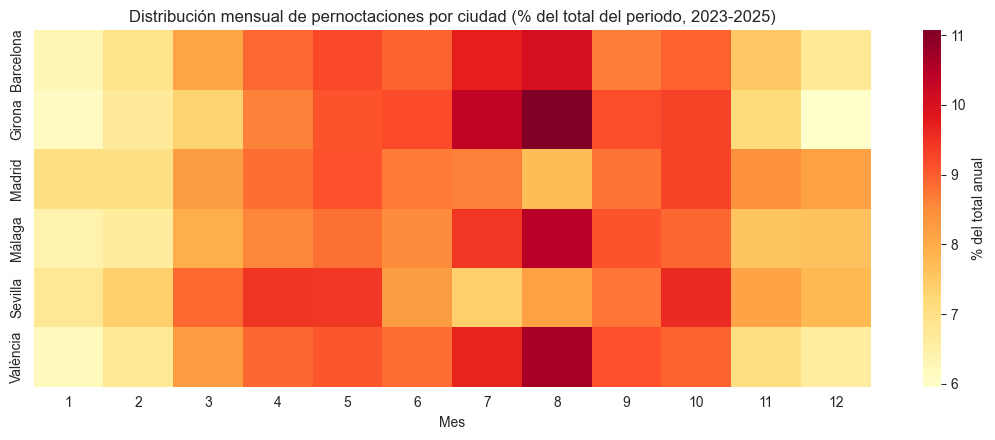

In [21]:
puntos_interes = list(MAPEO_PUNTO_TURISTICO.values())

sub_2078 = df_2078[
    df_2078["Puntos turísticos"].isin(puntos_interes)
    & (df_2078["Viajeros y pernoctaciones"] == "Pernoctaciones")
    & df_2078["Fecha"].between(PERIODO_INICIO, PERIODO_FIN)
].copy()
sub_2078["ciudad"] = sub_2078["Puntos turísticos"].str.replace(r"^\d+\s", "", regex=True)
sub_2078["mes"] = sub_2078["Fecha"].dt.month

estacionalidad_ciudades = sub_2078.groupby(["ciudad", "mes"])["Total_num"].sum().unstack("mes")
estacionalidad_pct = estacionalidad_ciudades.div(estacionalidad_ciudades.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.heatmap(estacionalidad_pct, cmap="YlOrRd", annot=False, cbar_kws={"label": "% del total anual"}, ax=ax)
ax.set_title("Distribución mensual de pernoctaciones por ciudad (% del total del periodo, 2023-2025)")
ax.set_xlabel("Mes")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

Se normaliza por ciudad (% del total del periodo) para comparar la *forma* de la estacionalidad con independencia del volumen. A diferencia del patrón por comunidad autónoma (sección 4.3), a nivel de ciudad las diferencias de forma son más sutiles: Girona es la que muestra una concentración algo más marcada en verano (pico en agosto). Madrid y Sevilla son las más planas de las 6, y en ambas el mes de mayor demanda es octubre en lugar de agosto —posiblemente por el calor extremo del verano en Sevilla y por un perfil de ciudad con turismo urbano/de negocio en Madrid, no solo vacacional—.

### 7.3. Procedencia nacional/extranjera por ciudad

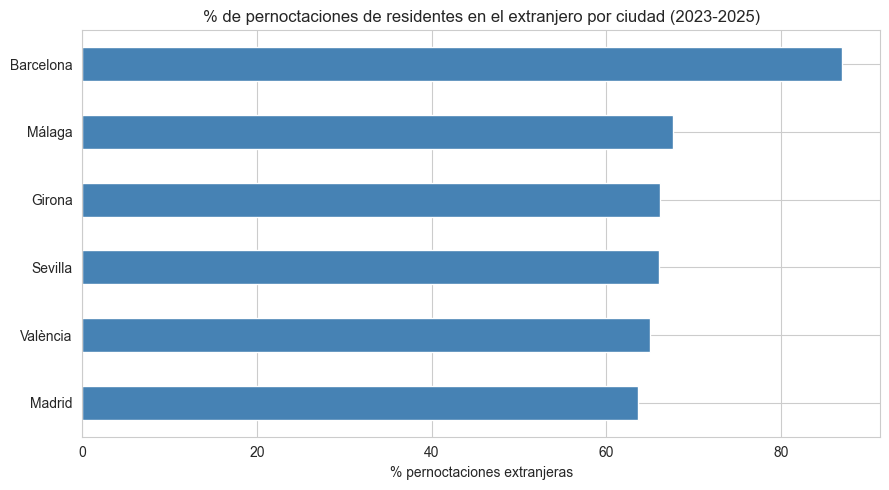

In [22]:
peso_origen_ciudades = sub_2078.pivot_table(index="ciudad", columns="Residencia", values="Total_num", aggfunc="sum")
peso_origen_ciudades["pct_extranjero"] = (
    peso_origen_ciudades["Residentes en el Extranjero"]
    / (peso_origen_ciudades["Residentes en España"] + peso_origen_ciudades["Residentes en el Extranjero"])
    * 100
).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
peso_origen_ciudades["pct_extranjero"].sort_values().plot(kind="barh", color="steelblue", ax=ax)
ax.set_title("% de pernoctaciones de residentes en el extranjero por ciudad (2023-2025)")
ax.set_xlabel("% pernoctaciones extranjeras")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

### 7.4. Estancia media por ciudad y procedencia

In [23]:
# Se recalcula sin filtrar por Viajeros y pernoctaciones (aquí se necesitan ambas
# categorías) y sumando los 3 años del periodo antes de dividir.
periodo_2078_completo = df_2078[
    df_2078["Puntos turísticos"].isin(puntos_interes)
    & df_2078["Fecha"].between(PERIODO_INICIO, PERIODO_FIN)
].copy()
periodo_2078_completo["ciudad"] = periodo_2078_completo["Puntos turísticos"].str.replace(r"^\d+\s", "", regex=True)

estancia_ciudades = periodo_2078_completo.pivot_table(
    index=["ciudad", "Residencia"],
    columns="Viajeros y pernoctaciones",
    values="Total_num",
    aggfunc="sum",
)
estancia_ciudades["estancia_media"] = (estancia_ciudades["Pernoctaciones"] / estancia_ciudades["Viajero"]).round(2)
estancia_ciudades[["estancia_media"]].unstack("Residencia")

Viajeros y pernoctaciones       estancia_media                            
Residencia                Residentes en España Residentes en el Extranjero
ciudad                                                                    
Barcelona                                 1.85                        2.69
Girona                                    1.48                        1.71
Madrid                                    1.69                        2.30
Málaga                                    1.79                        2.32
Sevilla                                   1.73                        2.33
València                                  1.82                        2.75

El patrón ya observado a nivel de comunidad autónoma (sección 4.2) se confirma a nivel de ciudad: la estancia media del viajero extranjero es sistemáticamente mayor que la del residente en España en las 6 ciudades analizadas.

## 8. Síntesis conjunta: comparativa de los 8 mercados de StaySpain (viajero extranjero)

Se combinan los resultados de las tablas 2078 (Barcelona, Madrid, Girona, València, Málaga, Sevilla) y 2039 (Mallorca, Menorca) para obtener, en un único cuadro, los tres indicadores clave de la pregunta de negocio para el **viajero extranjero**: mes de mayor demanda, peso sobre el total y estancia media, para cada uno de los 8 mercados donde StaySpain está presente.

In [24]:
def resumir_mercado_por_residencia(datos_completos, residencia):
    """Calcula mes pico, % sobre el total y estancia media de una procedencia (2023-2025)."""
    pernoctaciones_totales = datos_completos[datos_completos["Viajeros y pernoctaciones"] == "Pernoctaciones"]
    pernoctaciones_residencia = pernoctaciones_totales[pernoctaciones_totales["Residencia"] == residencia]

    por_mes = pernoctaciones_residencia.groupby(pernoctaciones_residencia["Fecha"].dt.month)["Total_num"].mean()
    mes_pico = int(por_mes.idxmax())

    piv = pernoctaciones_totales.pivot_table(index="Residencia", values="Total_num", aggfunc="sum")
    pct = piv.loc[residencia, "Total_num"] / piv["Total_num"].sum() * 100

    datos_residencia = datos_completos[datos_completos["Residencia"] == residencia]
    est_media = (
        datos_residencia[datos_residencia["Viajeros y pernoctaciones"] == "Pernoctaciones"]["Total_num"].sum()
        / datos_residencia[datos_residencia["Viajeros y pernoctaciones"] == "Viajero"]["Total_num"].sum()
    )
    return mes_pico, round(pct, 1), round(est_media, 2)


MERCADOS_2078 = [(ciudad, "2078 (punto turístico)", df_2078, "Puntos turísticos", punto)
                  for ciudad, punto in MAPEO_PUNTO_TURISTICO.items()]
MERCADOS_2039 = [(isla, "2039 (zona turística)", df_2039, "Zonas Turísticas", zona)
                  for isla, zona in MAPEO_ZONA_TURISTICA.items()]
MERCADOS_STAYSPAIN = MERCADOS_2078 + MERCADOS_2039

meses_nombre = {1: "ene", 2: "feb", 3: "mar", 4: "abr", 5: "may", 6: "jun",
                7: "jul", 8: "ago", 9: "sep", 10: "oct", 11: "nov", 12: "dic"}


def construir_resumen_mercados(residencia, nombre_columna_pct, nombre_columna_estancia, nombre_columna_mes):
    """Construye la tabla resumen de los 8 mercados de StaySpain para una procedencia dada."""
    filas = []
    for mercado, fuente, df_tabla, columna_geo, valor_geo in MERCADOS_STAYSPAIN:
        datos_completos = df_tabla[
            (df_tabla[columna_geo] == valor_geo)
            & df_tabla["Fecha"].between(PERIODO_INICIO, PERIODO_FIN)
        ]
        mes_pico, pct, est_media = resumir_mercado_por_residencia(datos_completos, residencia)
        filas.append({
            "mercado": mercado,
            "fuente": fuente,
            nombre_columna_mes: meses_nombre[mes_pico],
            nombre_columna_pct: pct,
            nombre_columna_estancia: est_media,
        })
    return pd.DataFrame(filas).sort_values(nombre_columna_pct, ascending=False).reset_index(drop=True)


resumen_mercados = construir_resumen_mercados(
    "Residentes en el Extranjero", "pct_extranjero", "estancia_media_extranjero", "mes_pico_extranjero"
)
resumen_mercados

,mercado,fuente,mes_pico_extranjero,pct_extranjero,estancia_media_extranjero
0,Mallorca,2039 (zona turística),ago,93.1,5.47
1,Barcelona,2078 (punto turístico),ago,87.0,2.69
2,Menorca,2039 (zona turística),ago,80.6,6.33
3,Málaga,2078 (punto turístico),ago,67.6,2.32
4,Girona,2078 (punto turístico),ago,66.2,1.71
5,Sevilla,2078 (punto turístico),oct,66.0,2.33
6,Valencia,2078 (punto turístico),ago,65.0,2.75
7,Madrid,2078 (punto turístico),oct,63.6,2.30


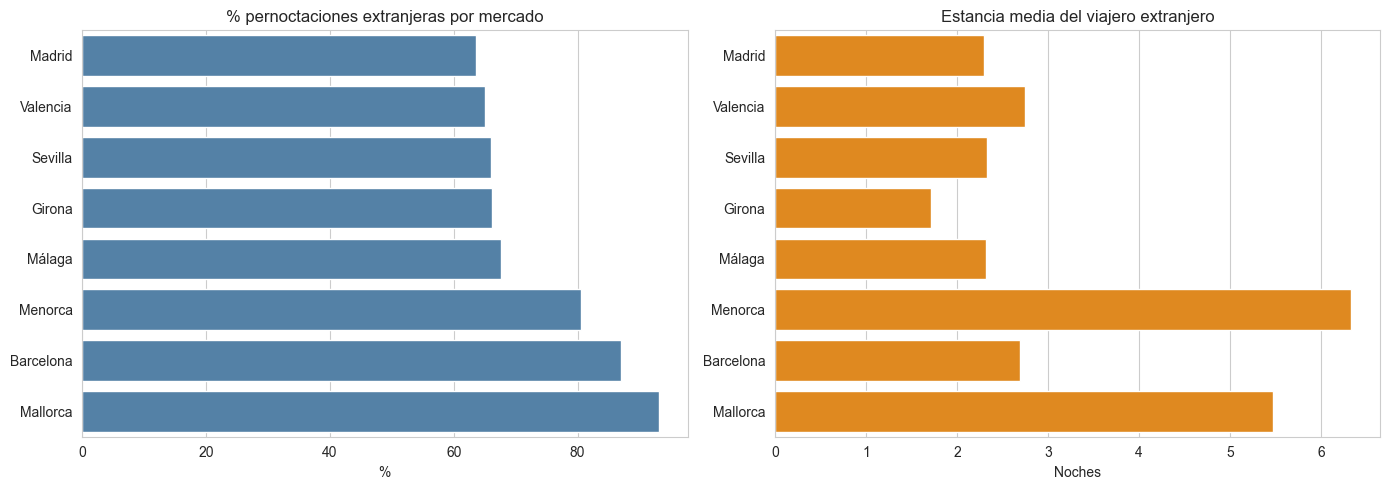

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

orden = resumen_mercados.sort_values("pct_extranjero")["mercado"]
sns.barplot(data=resumen_mercados, y="mercado", x="pct_extranjero", order=orden, color="steelblue", ax=axes[0])
axes[0].set_title("% pernoctaciones extranjeras por mercado")
axes[0].set_xlabel("%")
axes[0].set_ylabel("")

sns.barplot(data=resumen_mercados, y="mercado", x="estancia_media_extranjero", order=orden, color="darkorange", ax=axes[1])
axes[1].set_title("Estancia media del viajero extranjero")
axes[1].set_xlabel("Noches")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

El cuadro conjunto (2023-2025) no muestra una división limpia entre mercados "urbanos" y de "sol y playa": **Mallorca y Menorca** se distinguen claramente del resto en los dos ejes a la vez —máxima dependencia del turismo extranjero (93% y 81%) y estancias medias muy superiores (5,5 y 6,3 noches, frente a 1,7-2,8 en el resto)—, lo que confirma que son mercados de estancia vacacional larga, no equiparables a una ciudad. Entre las ciudades, **Barcelona** destaca por un peso del turismo extranjero (87%) casi al nivel de las islas pese a tener una estancia media corta (2,7 noches), típica de una ciudad; el resto de ciudades (Girona, Málaga, Sevilla, València y Madrid) forma un grupo mucho más homogéneo, entre el 64% y el 68% de turismo extranjero. **Madrid y Sevilla** son además las únicas con el pico de demanda en octubre en vez de agosto. En conjunto, el resultado más directo para la pregunta de negocio es que **las islas requieren una oferta claramente diferenciada del resto** (estancias mínimas más largas, fuerte estacionalidad estival, casi monolingüe en captación extranjera), **Barcelona** se acerca a las islas en dependencia del turismo extranjero pese a ser una ciudad de estancias cortas, y el resto de ciudades comparte un perfil de procedencia bastante similar entre sí, con Madrid y Sevilla diferenciándose únicamente en el mes de mayor demanda.

## 9. Síntesis conjunta: comparativa de los 8 mercados de StaySpain (viajero nacional)

Mismo ejercicio que en la sección 8, pero para el **viajero residente en España**: mes de mayor demanda, peso sobre el total y estancia media, para cada uno de los 8 mercados. Se reutiliza `resumir_mercado_por_residencia` (sección 8), cambiando únicamente la procedencia.

In [26]:
resumen_mercados_nacional = construir_resumen_mercados(
    "Residentes en España", "pct_nacional", "estancia_media_nacional", "mes_pico_nacional"
)
resumen_mercados_nacional

,mercado,fuente,mes_pico_nacional,pct_nacional,estancia_media_nacional
0,Madrid,2078 (punto turístico),dic,36.4,1.69
1,Valencia,2078 (punto turístico),mar,35.0,1.82
2,Sevilla,2078 (punto turístico),dic,34.0,1.73
3,Girona,2078 (punto turístico),nov,33.8,1.48
4,Málaga,2078 (punto turístico),ago,32.4,1.79
5,Menorca,2039 (zona turística),jul,19.4,4.01
6,Barcelona,2078 (punto turístico),mar,13.0,1.85
7,Mallorca,2039 (zona turística),ago,6.9,3.46


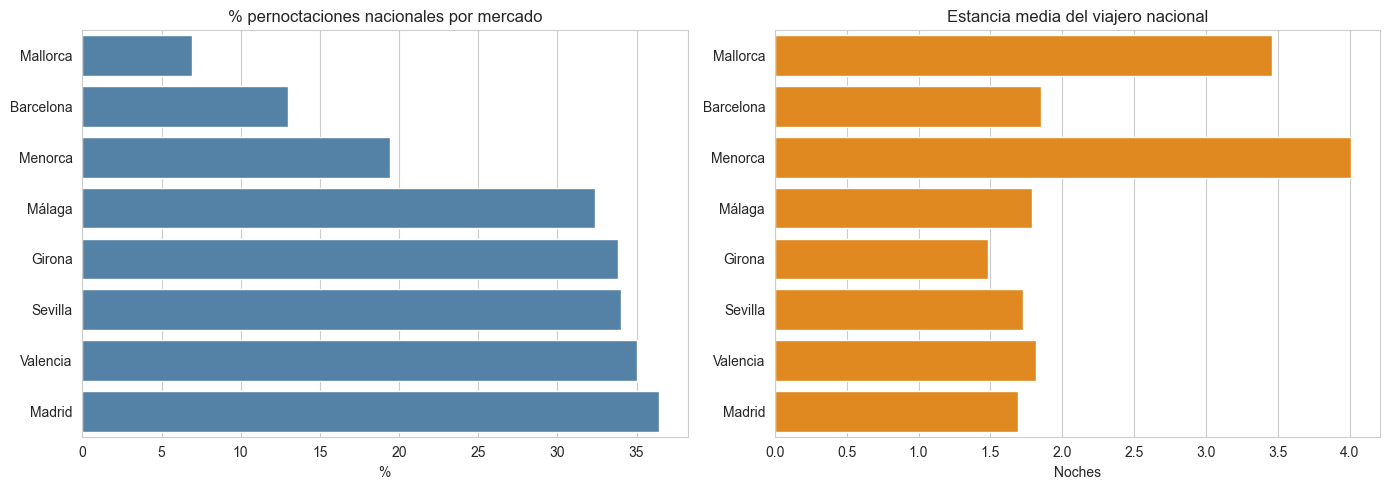

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

orden_nacional = resumen_mercados_nacional.sort_values("pct_nacional")["mercado"]
sns.barplot(data=resumen_mercados_nacional, y="mercado", x="pct_nacional", order=orden_nacional, color="steelblue", ax=axes[0])
axes[0].set_title("% pernoctaciones nacionales por mercado")
axes[0].set_xlabel("%")
axes[0].set_ylabel("")

sns.barplot(data=resumen_mercados_nacional, y="mercado", x="estancia_media_nacional", order=orden_nacional, color="darkorange", ax=axes[1])
axes[1].set_title("Estancia media del viajero nacional")
axes[1].set_xlabel("Noches")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [28]:
comparativa_mes_pico = resumen_mercados[["mercado", "mes_pico_extranjero"]].merge(
    resumen_mercados_nacional[["mercado", "mes_pico_nacional"]], on="mercado"
)
comparativa_mes_pico

,mercado,mes_pico_extranjero,mes_pico_nacional
0,Mallorca,ago,ago
1,Barcelona,ago,mar
2,Menorca,ago,jul
3,Málaga,ago,ago
4,Girona,ago,nov
5,Sevilla,oct,dic
6,Valencia,ago,mar
7,Madrid,oct,dic


El viajero nacional muestra un perfil claramente distinto al extranjero. Como cabía esperar por construcción, `pct_nacional` es exactamente `100 - pct_extranjero` (sección 8): Mallorca (6,9%) y Menorca (19,4%) siguen siendo los mercados con menor peso nacional, **Barcelona** también tiene un peso nacional bajo (13%) coherente con su elevada dependencia del extranjero, y las 5 ciudades restantes (Girona, Madrid, València, Sevilla y Málaga) se mueven todas en una banda estrecha, entre el 32% y el 36%.

La diferencia más relevante aparece en el **mes de mayor demanda**: en las islas (Mallorca, Menorca) el viajero nacional también prefiere el verano (julio-agosto), igual que el extranjero, coherente con un mercado de sol y playa sin distinción de origen. En las ciudades, en cambio, el viajero nacional se concentra en **periodos de puente y vacaciones escolares** en vez de en verano: Madrid y Sevilla en diciembre, Girona en noviembre, Barcelona y València en marzo (esta última probablemente ligada a las Fallas), mientras que sus respectivos picos de demanda extranjera son de verano (agosto) u octubre. La única excepción es **Málaga**, donde el viajero nacional también tiene su pico en agosto, igual que el extranjero, lo que sugiere un peso mayor del turismo de sol y playa nacional en esa ciudad frente al resto.

La estancia media del viajero nacional es, en todos los mercados, menor que la del extranjero (comparar con la sección 8), lo que confirma que la brecha de estancia por procedencia (sección 4.2) no es un artefacto de la agregación por comunidad autónoma, sino que se mantiene a nivel de cada ciudad y zona turística.

## 10. Conclusiones y próximos pasos

- Las 4 tablas de la EOH no se solapan: cada una aporta una pieza distinta de la pregunta de negocio (2074 → estancia media y estacionalidad por comunidad autónoma; 2069 → perfil de procedencia por provincia; 2039 → único nivel que distingue Mallorca de Menorca; 2078 → nivel más fino para el resto de ciudades). Ha sido necesario combinarlas para cubrir los 8 mercados de StaySpain.

- No se ha encontrado ningún registro duplicado ni incoherencia de formato más allá de las marcas `.`/`..` del INE (dato no disponible o secreto estadístico), que se han tratado como nulos sin imputar.

- La **estancia media es sistemáticamente mayor entre los viajeros extranjeros** que entre los residentes en España, en todas las comunidades autónomas y ciudades analizadas, y de forma especialmente marcada en Illes Balears.

- La **estacionalidad** por comunidad autónoma (2023-2025) es de tipo estival (pico en agosto) en Andalucía, Cataluña, Illes Balears y Comunitat Valenciana, con una intensidad muy distinta (rango pico-valle de ~18 puntos en Illes Balears frente a ~9-11 en las otras tres); Madrid es la excepción, con un patrón mucho más plano (rango de solo ~2,5 puntos) y pico en octubre. A nivel de ciudad el patrón es más matizado: Girona muestra la mayor concentración estacional de las 6 ciudades analizadas (pico en agosto); Madrid y Sevilla son las más planas y ambas tienen su pico en octubre en lugar de agosto, coincidiendo con el patrón ya visto para la Comunidad de Madrid a nivel de CCAA.

- No hay una división limpia entre mercados "de sol y playa" y "urbanos": **Mallorca y Menorca** se diferencian con claridad del resto (93% y 81% de pernoctaciones de extranjeros, estancias medias de 5,5 y 6,3 noches). Entre las ciudades, **Barcelona** tiene un peso del turismo extranjero (87%) casi tan alto como el de las islas pese a una estancia corta (2,7 noches); el resto de ciudades (Girona, Málaga, Sevilla, València y Madrid) es mucho más homogéneo, entre el 64% y el 68%.

- Estos resultados constituyen la base de **demanda oficial** que se contrastará con la oferta real de StaySpain (`EDA_21_07_2026.ipynb`) en un análisis posterior, para valorar si la oferta actual (tipología de alojamiento, disponibilidad estacional, idiomas/canales de captación) está alineada con el perfil y la estacionalidad de la demanda en cada ciudad.

- **Fuera de alcance de este notebook** (ver explicación en el chat): modelos predictivos/de forecasting, análisis de correlación u outliers a nivel de fila individual (no aplican a series oficiales agregadas), y el EDA exhaustivo de las 48 zonas turísticas / 138 puntos turísticos a nivel nacional, dado que la pregunta de negocio se centra específicamente en las ciudades donde StaySpain está presente.

## 11. Notas para Data Cleaning, Data Transformation y tareas de los analistas

Este apartado no es EDA: recoge, a partir de lo observado en las secciones anteriores, los puntos que deberían tenerse en cuenta en las siguientes fases formales del proyecto (Data Cleaning y Data Transformation) y cómo se reparte el trabajo de análisis de negocio entre los analistas del equipo.

### 11.1. Aspectos de interés para Data Cleaning

- **Marcas de secreto estadístico / dato no disponible (`.`, `..`):** decidir un criterio único de tratamiento (excluir vs. marcar con un flag `es_secreto_estadistico`) y documentarlo; en este EDA se han tratado como nulos sin imputar, pero no se ha decidido si eso es válido para todos los análisis posteriores (p. ej. en 2069, un `..` en un cruce provincia-CCAA con muy poco volumen no es lo mismo que un nulo estructural).
- **Columnas jerárquicas vacías o constantes:** `Totales Territoriales` (siempre "Total Nacional") y `Residencia: Nivel 1` (siempre "Total") no aportan información en ninguna de las 4 tablas y pueden eliminarse en la fase de limpieza.
- **Nombres de comunidades autónomas inconsistentes entre tablas:** 2039 usa `Baleares (Illes)` mientras que 2069/2074 usan `Balears, Illes`; conviene normalizar a una única grafía (idealmente con el código INE de 2 dígitos) antes de cualquier cruce entre tablas o con el dataset de StaySpain.
- **Filas agregadas mezcladas con el detalle:** las tablas 2069 y 2074 incluyen en el mismo fichero tanto el nivel agregado (`Provincias` o `Residencia: Nivel 2` nulos) como el detalle; hay que decidir si se separan en tablas distintas o se mantiene un indicador de nivel explícito, para evitar duplicar conteos en agregaciones futuras.
- **Formato de `Total` y de `Periodo`:** confirmado como consistente en las 4 tablas (miles con `.`, decimales con `,`; periodo `AAAAMmm`), por lo que el parseo puede formalizarse como un paso reproducible de limpieza en vez de resolverse solo dentro del EDA.
- **Duplicados:** no se ha encontrado ninguno en las 4 tablas; conviene mantener esta comprobación como test automatizado si se repite la descarga en el futuro.

### 11.2. Aspectos de interés para Data Transformation

- **Formalizar las columnas derivadas usadas en este EDA** (`Total_num`, `Fecha`, y a partir de ahí `año`/`mes`/`trimestre`, `estancia_media`, `pct_extranjero`/`pct_nacional`) como transformaciones reproducibles, en vez de recalcularlas en cada notebook de análisis.
- **Formalizar la tabla de correspondencia ciudad StaySpain ↔ unidad geográfica EOH** (`MAPEO_PUNTO_TURISTICO`, `MAPEO_ZONA_TURISTICA`, `MAPEO_PROVINCIA`, `MAPEO_CCAA` de la sección 3) como una tabla de dimensión propia, para no mantenerla duplicada en cada notebook que necesite cruzar StaySpain con la EOH.
- **Unificar las 4 tablas en un esquema "largo" único** (columnas: nivel_geografico, unidad_geografica, periodo, residencia, tipo_medida [viajero/pernoctación], valor), lo que simplificaría el filtrado y el futuro cruce con la oferta de StaySpain, actualmente repartido en 4 estructuras distintas.
- **Marcar 2026 como año en curso/incompleto** (flag `anio_completo`) para que otros análisis no lo mezclen sin querer con años completos como 2023-2025.
- **Variable de temporada (alta/media/baja) por mercado:** a la vista de la estacionalidad tan distinta encontrada en la sección 9 entre viajero nacional y extranjero, tiene sentido derivar esta variable de forma específica por procedencia y no solo por mes calendario.

### 11.3. Tareas de los analistas

Se propone repartir la investigación en profundidad de la pregunta de negocio en los mismos bloques que ha usado este EDA, de forma que cada analista se apoye en las tablas y hallazgos ya identificados aquí en vez de partir de cero:

1. **Procedencia de los viajeros** (tablas 2069 y secciones 4.4, 5, 8-9): profundizar en el perfil de origen por comunidad autónoma y ciudad, más allá del top 3 de la sección 5.2 (p. ej. concentración/diversificación del origen, evolución interanual) y entender mejor por qué València es la única ciudad cuyo origen doméstico principal no es su propia región, para proponer una segmentación de campañas de marketing nacional por origen geográfico.
2. **Meses de visita / estacionalidad** (tablas 2039, 2074, 2078 y secciones 4.3, 6.2, 7.2, 9): investigar con más detalle el hallazgo de la sección 9 —el viajero nacional se concentra en periodos de puente/vacaciones escolares mientras el extranjero lo hace en verano, con Málaga como excepción— y valorar su implicación en la disponibilidad y los precios por temporada.
3. **Media de pernoctaciones por comunidad autónoma** (tabla 2074 y secciones 4.2, 7.4, 8-9): profundizar en por qué la brecha de estancia media entre nacional y extranjero es mayor en Illes Balears que en el resto, y si esa brecha se traduce en una necesidad real de cambiar las estancias mínimas de StaySpain por ciudad.
4. **Estrategia de análisis y propuestas**: a partir de los tres puntos anteriores y del contraste con la oferta real de StaySpain (`EDA_21_07_2026.ipynb`), sintetizar propuestas concretas de ajuste de oferta (estancias mínimas, disponibilidad estacional, idiomas y canales de marketing por ciudad), diferenciando explícitamente islas, Barcelona y el resto de ciudades, tal como sugiere la síntesis de las secciones 8-9.